# NB02: PGP Gene Co-occurrence (H1)

**Hypothesis H1**: PGP trait genes co-occur non-randomly — species with nitrogen fixation are more likely to also carry pqqC and ipdC, suggesting functional selection for multi-trait PGPB.

**Steps:**
1. Build binary trait matrix (species × 5 focal traits)
2. Pairwise Fisher's exact tests for all 10 gene pairs → odds ratio + p-value
3. BH-FDR correction
4. Co-occurrence heatmap (seaborn clustermap)
5. Venn diagram of major trait combinations

**Input**: `data/species_pgp_matrix.csv`

**Output**: `data/pgp_cooccurrence.csv`, `figures/cooccurrence_heatmap.png`, `figures/cooccurrence_venn.png`

In [1]:
import os
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'pgp_pangenome_ecology')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

species_pgp = pd.read_csv(os.path.join(DATA, 'species_pgp_matrix.csv'))
print(f'Loaded species_pgp_matrix: {len(species_pgp):,} species')

Loaded species_pgp_matrix: 11,272 species


## 1. Build binary trait matrix

In [2]:
# Focal traits: one representative per pathway
# nifH = nitrogen fixation, pqqC = phosphate solubilization (central enzyme),
# acdS = ACC deaminase / ethylene reduction, ipdC = IAA biosynthesis, hcnC = HCN production
FOCAL_GENES = ['nifH', 'pqqC', 'acdS', 'ipdC', 'hcnC']

trait_matrix = species_pgp[['gtdb_species_clade_id'] + [f'{g}_present' for g in FOCAL_GENES]].copy()
trait_matrix.columns = ['species_id'] + FOCAL_GENES

N = len(trait_matrix)
print(f'Species in trait matrix: {N:,}')
print(f'\nPrevalence of each focal trait:')
for g in FOCAL_GENES:
    n = trait_matrix[g].sum()
    print(f'  {g:8s}: {n:6,} ({n/N*100:.1f}%)')

Species in trait matrix: 11,272

Prevalence of each focal trait:
  nifH    :  2,154 (19.1%)
  pqqC    :  2,621 (23.3%)
  acdS    :    430 (3.8%)
  ipdC    :    214 (1.9%)
  hcnC    :    774 (6.9%)


## 2. Pairwise Fisher's exact tests

In [3]:
def fisher_pair(df, gene_a, gene_b):
    """Compute 2x2 contingency table and Fisher's exact test for two binary genes."""
    a = df[gene_a].values
    b = df[gene_b].values
    both = ((a == 1) & (b == 1)).sum()
    a_only = ((a == 1) & (b == 0)).sum()
    b_only = ((a == 0) & (b == 1)).sum()
    neither = ((a == 0) & (b == 0)).sum()
    table = [[both, a_only], [b_only, neither]]
    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')
    return {
        'gene_a': gene_a, 'gene_b': gene_b,
        'n_both': int(both), 'n_a_only': int(a_only),
        'n_b_only': int(b_only), 'n_neither': int(neither),
        'odds_ratio': odds_ratio, 'p_value': p_value
    }


results = []
for ga, gb in combinations(FOCAL_GENES, 2):
    results.append(fisher_pair(trait_matrix, ga, gb))

cooccur_df = pd.DataFrame(results)

# BH-FDR correction
_, q_values, _, _ = multipletests(cooccur_df['p_value'], method='fdr_bh')
cooccur_df['q_value'] = q_values
cooccur_df['log2_or'] = np.log2(cooccur_df['odds_ratio'].clip(lower=1e-6))
cooccur_df['significant'] = cooccur_df['q_value'] < 0.05

print('Pairwise co-occurrence results (sorted by odds ratio):')
print(cooccur_df[['gene_a', 'gene_b', 'n_both', 'odds_ratio', 'p_value', 'q_value', 'significant']]
      .sort_values('odds_ratio', ascending=False).to_string(index=False))

cooccur_df.to_csv(os.path.join(DATA, 'pgp_cooccurrence.csv'), index=False)
print(f'\nSaved pgp_cooccurrence.csv')

Pairwise co-occurrence results (sorted by odds ratio):
gene_a gene_b  n_both  odds_ratio      p_value      q_value  significant
  pqqC   acdS     286    7.235909 1.166497e-84 1.166497e-83         True
  pqqC   hcnC     275    1.914998 1.236270e-15 3.090675e-15         True
  acdS   hcnC      45    1.621453 4.564276e-03 5.705345e-03         True
  pqqC   ipdC      68    1.551599 4.110615e-03 5.705345e-03         True
  nifH   acdS     113    1.537122 2.130765e-04 4.261530e-04         True
  nifH   ipdC      45    1.129858 4.823707e-01 5.359675e-01        False
  acdS   ipdC       8    0.978788 1.000000e+00 1.000000e+00        False
  nifH   pqqC     345    0.573312 8.605022e-20 2.868341e-19         True
  ipdC   hcnC       4    0.254496 1.468007e-03 2.446678e-03         True
  nifH   hcnC      42    0.227824 1.164490e-29 5.822452e-29         True

Saved pgp_cooccurrence.csv


## 3. Co-occurrence heatmap

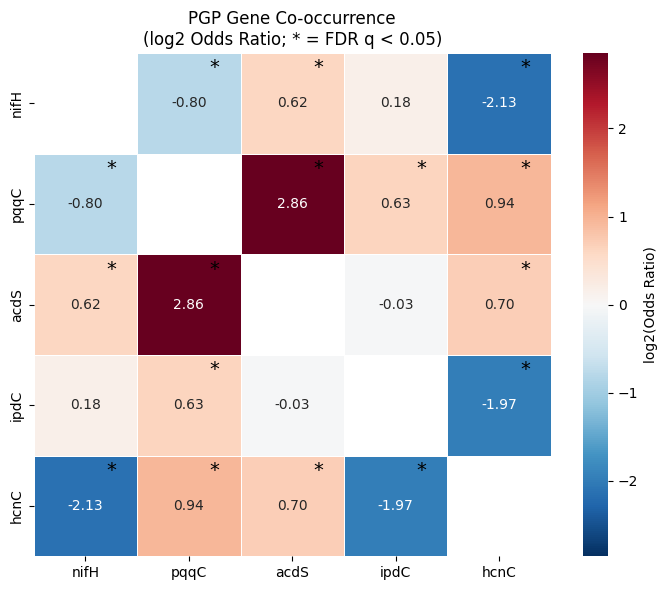

Saved figures/cooccurrence_heatmap.png


In [4]:
# Build symmetric log2(OR) matrix for heatmap
or_matrix = pd.DataFrame(0.0, index=FOCAL_GENES, columns=FOCAL_GENES)
np.fill_diagonal(or_matrix.values, np.nan)  # diagonal = NaN

for _, row in cooccur_df.iterrows():
    or_matrix.loc[row['gene_a'], row['gene_b']] = row['log2_or']
    or_matrix.loc[row['gene_b'], row['gene_a']] = row['log2_or']

# Significance mask
sig_matrix = pd.DataFrame(False, index=FOCAL_GENES, columns=FOCAL_GENES)
for _, row in cooccur_df.iterrows():
    sig_matrix.loc[row['gene_a'], row['gene_b']] = row['significant']
    sig_matrix.loc[row['gene_b'], row['gene_a']] = row['significant']

fig, ax = plt.subplots(figsize=(7, 6))
vmax = max(abs(or_matrix.values[~np.isnan(or_matrix.values)])) if or_matrix.notna().any().any() else 3
sns.heatmap(
    or_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-vmax, vmax=vmax,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'log2(Odds Ratio)'}
)
# Mark significant pairs with asterisk
for i, ga in enumerate(FOCAL_GENES):
    for j, gb in enumerate(FOCAL_GENES):
        if sig_matrix.loc[ga, gb]:
            ax.text(j + 0.75, i + 0.2, '*', fontsize=14, color='black', ha='center')

ax.set_title('PGP Gene Co-occurrence\n(log2 Odds Ratio; * = FDR q < 0.05)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'cooccurrence_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/cooccurrence_heatmap.png')

## 4. Multi-trait combination counts (Venn-style)

Top 20 trait combinations:
trait_combo
none                   6135
pqqC                   1812
nifH                   1738
hcnC                    452
pqqC+hcnC               235
nifH+pqqC               225
pqqC+acdS               153
ipdC                    124
acdS                    121
nifH+pqqC+acdS           90
pqqC+ipdC                40
nifH+hcnC                36
pqqC+acdS+hcnC           33
nifH+ipdC                20
nifH+pqqC+ipdC           19
nifH+acdS                14
acdS+hcnC                 8
nifH+pqqC+acdS+ipdC       6
nifH+pqqC+hcnC            3
nifH+pqqC+acdS+hcnC       2

Species with >=3 PGP traits: 157 (1.4%)


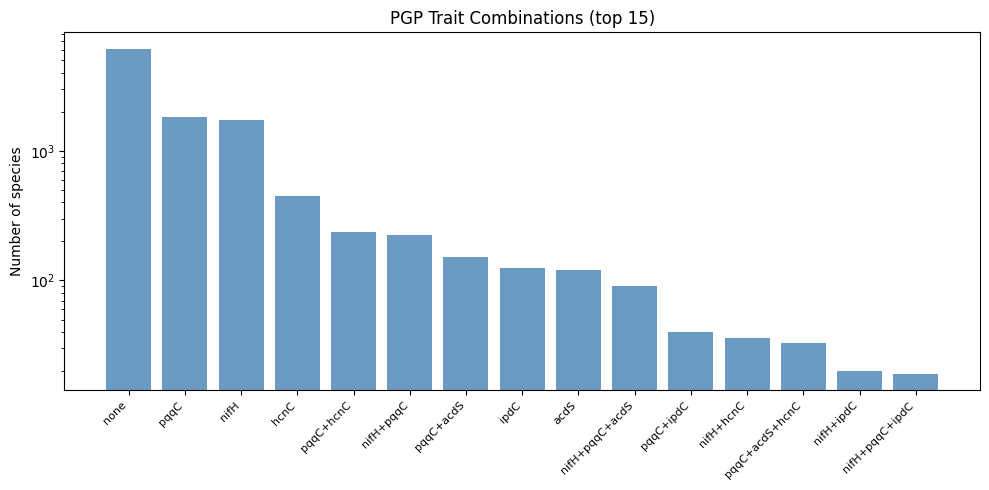

Saved figures/cooccurrence_combinations.png


In [5]:
# Count species by combination of major traits
trait_matrix['trait_combo'] = trait_matrix[FOCAL_GENES].apply(
    lambda row: '+'.join([g for g in FOCAL_GENES if row[g] == 1]) or 'none', axis=1
)

combo_counts = trait_matrix['trait_combo'].value_counts()
print('Top 20 trait combinations:')
print(combo_counts.head(20).to_string())

# Multi-trait species (>=3 PGP genes)
multi_trait = (trait_matrix[FOCAL_GENES].sum(axis=1) >= 3).sum()
print(f'\nSpecies with >=3 PGP traits: {multi_trait:,} ({multi_trait/N*100:.1f}%)')

# Bar chart of combo counts
fig, ax = plt.subplots(figsize=(10, 5))
top_combos = combo_counts.head(15)
ax.bar(range(len(top_combos)), top_combos.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(top_combos)))
ax.set_xticklabels(top_combos.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of species')
ax.set_title('PGP Trait Combinations (top 15)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'cooccurrence_combinations.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/cooccurrence_combinations.png')

In [6]:
# H1 summary
print('=== H1 Summary: PGP Co-occurrence ===')
sig_pairs = cooccur_df[cooccur_df['significant']]
print(f'Significant co-occurring pairs (FDR q<0.05): {len(sig_pairs):,} / {len(cooccur_df)}')
if len(sig_pairs) > 0:
    pos_pairs = sig_pairs[sig_pairs['odds_ratio'] > 1]
    neg_pairs = sig_pairs[sig_pairs['odds_ratio'] < 1]
    print(f'  Positive co-occurrence (OR>1): {len(pos_pairs)}')
    print(f'  Negative co-occurrence (OR<1): {len(neg_pairs)}')
    print(f'\nStrongest positive pairs:')
    print(pos_pairs.nlargest(5, 'odds_ratio')[['gene_a','gene_b','n_both','odds_ratio','q_value']].to_string(index=False))

h1_supported = len(sig_pairs[sig_pairs['odds_ratio'] > 1]) > 0
print(f'\nH1 supported: {h1_supported}')

=== H1 Summary: PGP Co-occurrence ===
Significant co-occurring pairs (FDR q<0.05): 8 / 10
  Positive co-occurrence (OR>1): 5
  Negative co-occurrence (OR<1): 3

Strongest positive pairs:
gene_a gene_b  n_both  odds_ratio      q_value
  pqqC   acdS     286    7.235909 1.166497e-83
  pqqC   hcnC     275    1.914998 3.090675e-15
  acdS   hcnC      45    1.621453 5.705345e-03
  pqqC   ipdC      68    1.551599 5.705345e-03
  nifH   acdS     113    1.537122 4.261530e-04

H1 supported: True
